## Installing the required libraries

In [ ]:
%pip install -q "diffusers>=0.33.0" "transformers>=4.49.0" "accelerate>=1.4.0" \
                ftfy sentencepiece "imageio[ffmpeg]"

## Load the model

A few design choices worth listing:

- **VAE in `float32`** - Wan's VAE is numerically sensitive; running it in bf16 causes color artifacts. The transformer (which is the heavy part) stays in bf16.
- **`UniPCMultistepScheduler` with `flow_shift=3.0`** - Wan uses Flow Matching; `flow_shift` controls the noise schedule's curvature. The Wan team recommends `3.0` for 480p, `5.0` for 720p.
- **Memory strategy auto-picked from GPU VRAM** - on an L4 or A100 (≥20GB), we keep everything on GPU for max speed. On smaller GPUs we fall back to `enable_model_cpu_offload()`.
- **Manual UMT5 weight-tying fix** - the released checkpoint relies on the text encoder's input embedding being tied to `shared.weight`, but current `transformers` versions don't restore this tie on load. Without our patch, the encoder produces zero outputs and generation degenerates to a uniform gray video. We restore the tie manually after load.

First run downloads ~7GB of weights from Hugging Face and takes a few minutes.

In [ ]:
import torch
from diffusers import AutoencoderKLWan, WanPipeline
from diffusers.schedulers.scheduling_unipc_multistep import UniPCMultistepScheduler

MODEL_ID = "Wan-AI/Wan2.1-T2V-1.3B-Diffusers"

vae = AutoencoderKLWan.from_pretrained(MODEL_ID, subfolder="vae", torch_dtype=torch.float32)
pipe = WanPipeline.from_pretrained(MODEL_ID, vae=vae, torch_dtype=torch.bfloat16)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config, flow_shift=3.0)


te = pipe.text_encoder
te.encoder.embed_tokens.weight = te.shared.weight
assert te.encoder.embed_tokens.weight.data_ptr() == te.shared.weight.data_ptr(), \
    "Text encoder weight tying failed"

vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
if vram_gb >= 20:
    pipe.to("cuda")
    print(f"GPU has {vram_gb:.1f} GB.")
else:
    pipe.enable_model_cpu_offload()
    print(f"GPU has {vram_gb:.1f} GB")

pipe.vae.enable_tiling()

print("Pipeline ready.")

## Inference helper

The filename embeds the seed and a slug of the prompt so outputs are traceable when we start running comparison experiments.

**Constraints to know:**
- `num_frames` must satisfy `(num_frames - 1) % 4 == 0` (VAE temporal scale = 4). `81` gives a 5s clip at 16fps.
- `height` and `width` must be multiples of 16. `(480, 832)` is the recommended 480p shape.
- The Wan team's default negative prompt is verbose Chinese; this is the English version they provide in their examples.
- **720p is technically available** on 1.3B (use `height=720, width=1280` and switch `flow_shift` to `5.0` in the scheduler cell). The Wan team flags it as less stable than 480p since the 1.3B model was trained primarily at 480p, so it's fine for one-off showcases. It's not ideal for systematic experiments where we want consistent behavior.

In [9]:
import re, time
from pathlib import Path
from diffusers.utils import export_to_video

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

DEFAULT_NEGATIVE = (
    "Bright tones, overexposed, static, blurred details, subtitles, style, works, "
    "paintings, images, static, overall gray, worst quality, low quality, JPEG "
    "compression residue, ugly, incomplete, extra fingers, poorly drawn hands, "
    "poorly drawn faces, deformed, disfigured, malformed limbs, fused fingers, "
    "still picture, cluttered background, three legs, many people in the background, walking backwards"
)

def slugify(text, max_len=40):
    s = re.sub(r"[^a-zA-Z0-9]+", "_", text.lower()).strip("_")
    return s[:max_len]

Connecting to Google Drive to load the images

In [ ]:
import os, glob
from PIL import Image

from google.colab import drive
drive.mount("/content/drive")

ASSET_DIR = "/content/drive/MyDrive/EE243/Project"

print(f"ASSET_DIR → {ASSET_DIR}")

exts = ("*.jpg", "*.jpeg", "*.png", "*.webp")
found = []
for ext in exts:
    found.extend(glob.glob(os.path.join(ASSET_DIR, ext)))
found.sort()
print(f"\nFound {len(found)} image(s):")
for p in found:
    print(f"  {os.path.basename(p)}")

Verifying pipeline

In [ ]:
from diffusers import WanVideoToVideoPipeline
pipe_i2v = WanVideoToVideoPipeline.from_pipe(pipe)
print("Ready")

Setting up a function to generate the video so we only have to write it once and can call multiple times. 

In [ ]:
from PIL import Image as PILImage

def generate_i2v(image_pil, prompt, negative_prompt=DEFAULT_NEGATIVE,
                 height=480, width=832, num_frames=81,
                 num_inference_steps=30, guidance_scale=5.0,
                 strength=0.80, seed=0, fps=16, tag=""):
    img_resized = image_pil.convert("RGB").resize((width, height), PILImage.LANCZOS)
    video_frames = [img_resized] * num_frames 

    generator = torch.Generator("cpu").manual_seed(seed)

    t0 = time.time()
    result = pipe_i2v(
        video=video_frames,
        prompt=prompt,
        negative_prompt=negative_prompt,
        height=height, width=width,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale, 
        strength=strength,
        generator=generator,
    )
    elapsed = time.time() - t0

    frames = result.frames[0]
    name_parts = [p for p in [tag, slugify(prompt), f"seed{seed}"] if p]
    out_path = OUTPUT_DIR / ("__".join(name_parts) + ".mp4")
    export_to_video(frames, str(out_path), fps=fps)

    print(f"Saved {out_path.name}  ({elapsed:.1f}s)  [strength={strength}]")
    return out_path

## Experiment 3

Experiement with the cartoon image into a photorealistic image.

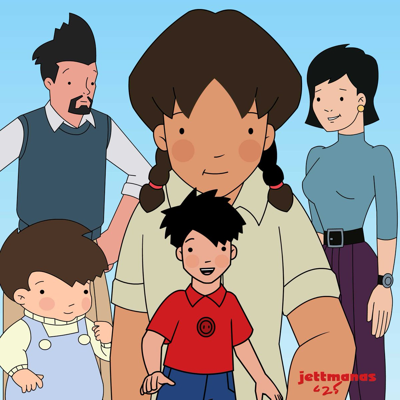

Input: /content/drive/MyDrive/EE243/Project/Cartoon.jpg  (1200×1200)


  0%|          | 0/24 [00:00<?, ?it/s]

Saved i2v_cartoon__the_illustrated_scene_comes_to_life_with__seed42.mp4  (605.2s)  [strength=0.8]


In [ ]:
from PIL import Image

CARTOON_IMAGE = "Cartoon.jpg"

cartoon_path = os.path.join(ASSET_DIR, CARTOON_IMAGE)
cartoon_img = Image.open(cartoon_path).convert("RGB")

preview = cartoon_img.copy()
preview.thumbnail((600, 400))
display(preview)
print(f"Input: {cartoon_path}  ({cartoon_img.width}×{cartoon_img.height})")

cartoon_prompt = (
    "The illustrated scene comes to life with smooth, fluid motion. "
    "Characters move naturally, fabric sways gently in the breeze, "
    "light dances across the scene. Vibrant colors, hand-drawn animation quality."
)
cartoon_negative = DEFAULT_NEGATIVE + ", photorealistic, 3D render"

cartoon_video = generate_i2v(
    image_pil=cartoon_img,
    prompt=cartoon_prompt,
    negative_prompt=cartoon_negative,
    tag="i2v_cartoon",
    seed=42,
)


## Experiment 4

Experiment with bringing a photo to life

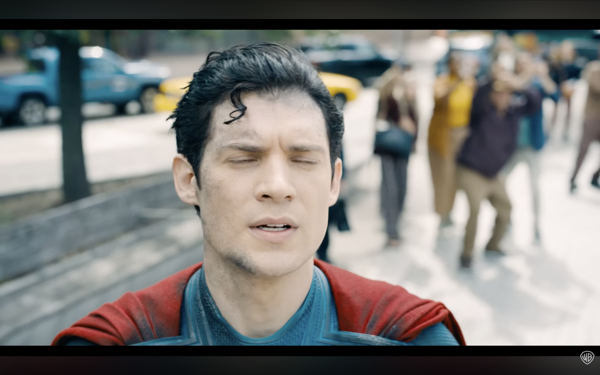

Input: /content/drive/MyDrive/EE243/Project/Movie_Clip_2.png  (3024×1892)


  0%|          | 0/24 [00:00<?, ?it/s]

Saved i2v_photo__the_scene_comes_alive_with_gentle_natura__seed42.mp4  (603.6s)  [strength=0.8]


In [ ]:
PHOTO_IMAGE = "Movie_Clip_2.png"   

photo_path = os.path.join(ASSET_DIR, PHOTO_IMAGE)
photo_img = Image.open(photo_path).convert("RGB")

preview = photo_img.copy()
preview.thumbnail((600, 400))
display(preview)
print(f"Input: {photo_path}  ({photo_img.width}×{photo_img.height})")

photo_prompt = (
    "The scene comes alive with gentle, natural motion — "
    "leaves rustle, people shift slightly, light moves across surfaces. "
    "Photorealistic, cinematic, 4K, smooth and natural."
)

photo_video = generate_i2v(
    image_pil=photo_img,
    prompt=photo_prompt,
    tag="i2v_photo",
    seed=42,
)

## Experiment 5

Experiment with the extending a frame of an animated movie

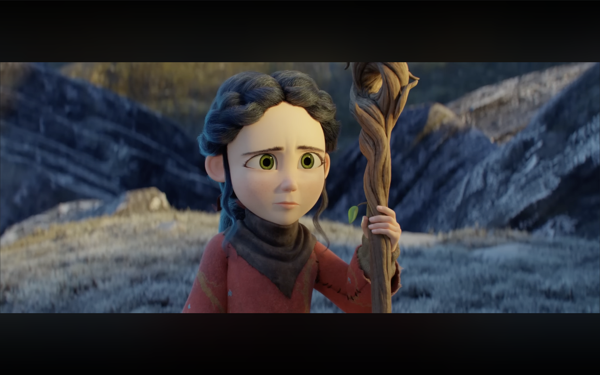

Input: /content/drive/MyDrive/EE243/Project/Movie_Clip.png  (3024×1892)


  0%|          | 0/24 [00:00<?, ?it/s]

Saved i2v_movie__the_cinematic_scene_continues_with_smoot__seed42.mp4  (603.5s)  [strength=0.8]


In [ ]:
MOVIE_IMAGE = "Movie_Clip.png"  

movie_path = os.path.join(ASSET_DIR, MOVIE_IMAGE)
movie_img = Image.open(movie_path).convert("RGB")

preview = movie_img.copy()
preview.thumbnail((600, 400))
display(preview)
print(f"Input: {movie_path}  ({movie_img.width}×{movie_img.height})")

movie_prompt = (
    "The cinematic scene continues with smooth, natural motion consistent with the film's style. "
    "Camera moves naturally, characters and objects move as they would in the original footage. "
    "Photorealistic, high-quality cinematography, consistent lighting and atmosphere."
)

movie_video = generate_i2v(
    image_pil=movie_img,
    prompt=movie_prompt,
    tag="i2v_movie",
    seed=42,
    guidance_scale=6.0,
)

Savign all the generated content in Google Drive

In [ ]:
import shutil
from pathlib import Path

DRIVE_OUT = Path(ASSET_DIR) / "generated"
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

copied = 0
for f in Path("outputs").iterdir():
    if f.is_file():
        shutil.copy2(f, DRIVE_OUT / f.name)
        copied += 1

print(f"Copied {copied} files")